In [26]:
from dotenv import load_dotenv
import os
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, r2_score, mean_absolute_error, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import re
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

In [9]:
load_dotenv()

db_user = os.getenv('DB_USER')
db_pass = os.getenv('DB_PASS')
db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')
db_name = os.getenv('DB_NAME')

engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}")

In [10]:
df_games = pd.read_sql("SELECT * FROM games", engine)
df_players = pd.read_sql('SELECT * FROM players', engine)
df_player_games = pd.read_sql('SELECT * FROM player_game_stats', engine)
df_teams = pd.read_sql('SELECT * FROM teams', engine)
df_venues = pd.read_sql('SELECT * FROM venues', engine)
df_team_venues = pd.read_sql("SELECT * FROM team_home_venue", engine)

cols_to_drop = [
    'kaggle_home_ht_score', 'kaggle_home_3qt_score', 'kaggle_home_ft_score',
    'kaggle_away_qt_score', 'kaggle_away_ht_score', 'kaggle_away_3qt_score',
    'kaggle_away_ft_score', 'kaggle_home_qt_score', 'afltables_game_id'
]

df_games = df_games.drop(columns=[col for col in cols_to_drop if col in df_games.columns])


In [11]:
# Helper function to sort players into roles
h_cutoff = 195
def assign_position_group(row):
    pos = row['position'].lower().replace(' ', '') if row['position'] else ''
    if 'defender' in pos:
        if row['height_cm'] is not None and row['height_cm'] >= 195:
            return ['tall_defender']
        elif row['height_cm'] is not None and row['height_cm'] < 195:
            return ['small_defender']
        else:
            return ['small_defender']  # fallback if height unknown
    if pos == 'midfield,forward':
        return ['midfield,forward']
    return pos.split(',') if pos else []

In [12]:
# Helper function for win/loss
def get_team_win(row):
    if row['team_id'] == row['home_team_id']:
        return 1 if row['home_result'] == 'W' else 0
    elif row['team_id'] == row['away_team_id']:
        return 1 if row['away_result'] == 'W' else 0
    else:
        return None  

In [13]:
# Helper function for distance
def distance_np(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R * c

In [14]:
# Helper function to sort rounds
def get_round_order(row):
    # Match regular rounds: 'R1', 'R23', etc.
    match = re.match(r'R(\d+)$', row['round'])
    if match:
        return int(match.group(1))
    # Finals rounds mapping (AFL convention)
    finals_order = {
        'REF': 100,  # Elimination Final (week 1)
        'RQF': 101,  # Qualifying Final (week 1)
        'RSF': 102,  # Semi Final (week 2)
        'RPF': 103,  # Preliminary Final (week 3)
        'RGF': 104,  # Grand Final (week 4)
    }
    code = row['round'][1:] 
    return finals_order.get(code, 999)  # Unknown finals get 999

In [15]:
# sort rounds
df_games['round_order'] = df_games.apply(get_round_order, axis=1)
df_games = df_games.sort_values(['season_year', 'round_order', 'game_date']).reset_index(drop=True)

In [16]:
# Distance & Home Ground Advantage
# Merge data together
# First, split out the lat and long from a single column
df_venues[['lat', 'lon']] = df_venues['location'].str.split(',', expand=True)
df_venues['lat'] = df_venues['lat'].astype(float)
df_venues['lon'] = df_venues['lon'].astype(float)

# Merge teams with venues to get each team's home ground location
teams_home = df_teams.merge(
    df_venues[['id', 'lat', 'lon']],
    left_on='home_ground',
    right_on='id',
    suffixes=('', '_venue')
).rename(columns={'lat': 'lat_home', 'lon': 'lon_home'})
teams_home = teams_home.rename(columns={'id': 'home_team_id', 'lat': 'lat_home', 'lon': 'lon_home', 'state': 'home_state'})

# Merge games with home team location
df_home_ground = df_games.merge(
    teams_home,
    left_on='home_team_id',
    right_on='home_team_id',  
    suffixes=('', '_home')
)

# Merge games with venues to get venue lat/lon
df_home_ground = df_home_ground.merge(
    df_venues[['id', 'lat', 'lon']],
    left_on='venue_id',
    right_on='id',
    suffixes=('', '_venue')
).rename(columns={'lat': 'lat_venue', 'lon': 'lon_venue'})

# Calculate distance
df_home_ground['distance_from_home'] = distance_np(
    df_home_ground['lat_home'],
    df_home_ground['lon_home'],
    df_home_ground['lat_venue'],
    df_home_ground['lon_venue']
)

# Adding in interstate flag (calling out geelong as another state)
teams_away = df_teams[['id', 'state']].rename(columns={'id': 'away_team_id', 'state': 'away_state'})
df_home_ground = df_home_ground.merge(
    teams_away,
    on='away_team_id',
    how='left'
)

# Determine if home venue
df_home_ground = df_home_ground.merge(
    df_team_venues,
    how='left',
    left_on=['home_team_id', 'venue_id'],
    right_on=['team_id', 'venue_id'],
    indicator=True
)
df_home_ground['neutral_venue'] = df_home_ground['_merge'] == 'left_only'
df_home_ground = df_home_ground.drop(columns=['team_id', '_merge'])

df_home_ground['home_state'] = df_home_ground.apply(lambda row: 'GEELONG' if row['home_team_id'] == 20710 else row['home_state'], axis=1)
df_home_ground['away_state'] = df_home_ground.apply(lambda row: 'GEELONG' if row['away_team_id'] == 20710 else row['away_state'], axis=1)

df_home_ground['interstate'] = df_home_ground['home_state'] != df_home_ground['away_state']

# Add columnf or home game win or not
df_home_ground['home_team_win'] = df_home_ground['home_result'].map({'W': 1, 'L': 0, 'D': 0.5})


In [17]:
# team momentum

# calculate rolling averages of previous 5 games
df_games['game_date'] = pd.to_datetime(df_games['game_date'])

df_home = df_games[['id', 'season_year', 'round', 'game_date', 'home_team_id', 'home_score_total', 'away_score_total']].copy()
df_home = df_home.rename(columns={
    'home_team_id': 'team_id',
    'home_score_total': 'score_scored',
    'away_score_total': 'score_conceded'
})

df_away = df_games[['id', 'season_year', 'round', 'game_date', 'away_team_id', 'away_score_total', 'home_score_total']].copy()
df_away = df_away.rename(columns={
    'away_team_id': 'team_id',
    'away_score_total': 'score_scored',
    'home_score_total': 'score_conceded'
})

df_momentum = pd.concat([df_home, df_away], ignore_index=True)
df_momentum = df_momentum.sort_values(['team_id', 'game_date']).reset_index(drop=True)

# calculate average score and margin based on rolling average of previous 5 games, minimum 1 game and only including games in season
df_momentum['avg_scored_prev5'] = (
    df_momentum.groupby(['team_id', 'season_year'])['score_scored']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df_momentum['avg_conceded_prev5'] = (
    df_momentum.groupby(['team_id', 'season_year'])['score_conceded']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

df_momentum['margin'] = df_momentum['score_scored'] - df_momentum['score_conceded']

df_momentum['avg_margin_prev5'] = (
    df_momentum.groupby(['team_id', 'season_year'])['margin']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
print(df_momentum.head())

      id  season_year round  game_date  team_id  score_scored  score_conceded  \
0  13346         2010    R1 2010-03-27        5           114              82   
1  13350         2010    R2 2010-04-01        5           107              88   
2  13360         2010    R3 2010-04-10        5           108              81   
3  13370         2010    R4 2010-04-17        5           101              79   
4  13376         2010    R5 2010-04-24        5            53             103   

   avg_scored_prev5  avg_conceded_prev5  margin  avg_margin_prev5  
0               NaN                 NaN      32               NaN  
1        114.000000           82.000000      19              32.0  
2        110.500000           85.000000      27              25.5  
3        109.666667           83.666667      22              26.0  
4        107.500000           82.500000     -50              25.0  


In [18]:
# ELO feature

START_ELO = 1500
K = 40
HGA = 50
ELO_SOFT_RESET = 0.75

# Initialize ELO ratings
teams = pd.concat([df_games['home_team_id'], df_games['away_team_id']]).unique()
elo = {team: START_ELO for team in teams}
home_elo_history, away_elo_history = [], []
elo_history = []

for idx, row in df_games.iterrows():
    if idx > 0 and row['season_year'] != df_games.loc[idx-1, 'season_year']:
        for team in elo:
            elo[team] = elo[team] * ELO_SOFT_RESET + START_ELO * (1 - ELO_SOFT_RESET)

    home, away = row['home_team_id'], row['away_team_id']
    home_elo, away_elo = elo[home], elo[away]

    # Store pre-game ELO for both teams
    elo_history.append({
        'game_id': row['id'],
        'team_id': home,
        'elo_pre_game': home_elo,
        'is_home': True
    })
    elo_history.append({
        'game_id': row['id'],
        'team_id': away,
        'elo_pre_game': away_elo,
        'is_home': False
    })

    exp_home = 1 / (1 + 10 ** ((away_elo - (home_elo + HGA)) / 400))

    if row['home_score_total'] > row['away_score_total']:
        s_home, s_away = 1, 0
    elif row['home_score_total'] < row['away_score_total']:
        s_home, s_away = 0, 1
    else:
        s_home = s_away = 0.5

    elo[home] += K * (s_home - exp_home)
    elo[away] += K * (s_away - (1 - exp_home))
    
df_elo = pd.DataFrame(elo_history)
print(df_elo.head())


   game_id  team_id  elo_pre_game  is_home
0    13342    20065        1500.0     True
1    13342    19974        1500.0    False
2    13343    20710        1500.0     True
3    13343    20434        1500.0    False
4    13344    19881        1500.0     True


In [19]:
# Age feature
query_age = """
SELECT 
    pgs.game_id, 
    pgs.team_id, 
    pgs.player_id, 
    p.birth_date, 
    g.game_date,
    g.home_team_id,
    g.away_team_id,
    g.home_score_total,
    g.away_score_total
FROM player_game_stats pgs
JOIN games g ON pgs.game_id = g.id
JOIN players p ON pgs.player_id = p.id
"""
df_players_age = pd.read_sql(query_age, engine)

df_players_age['age_at_game'] = (
    (pd.to_datetime(df_players_age['game_date']) - pd.to_datetime(df_players_age['birth_date'])).dt.days / 365.25
)

df_team_age = (
    df_players_age
      .groupby(['game_id', 'team_id'])['age_at_game']
      .agg([
          ('avg_age','mean'),
      ])
      .reset_index()
)


In [24]:
# Player model - not used
# Clean position data, with midfield,forward being it's own group
def custom_position_split(pos_str):
    if not pos_str or pd.isnull(pos_str):
        return []
    pos_str = pos_str.lower().replace(' ', '')
    if pos_str == 'midfield,forward':
        return ['midfield,forward']
    return pos_str.split(',')

players = pd.read_sql('SELECT id as player_id, full_name, height_cm, position FROM players', engine)
players['position_group'] = players.apply(assign_position_group, axis=1)
players_exploded = players.explode('position_group')
players_exploded = players_exploded[players_exploded['position_group'] != '']

# Merge tables to get results
df_player_impact = df_player_games.merge(
    df_games[['id', 'game_date', 'home_team_id', 'away_team_id', 'home_result', 'away_result']],
    left_on='game_id',
    right_on='id',
    how='left'
)

# Add in the positions from the position data above
df_player_impact = df_player_impact.merge(
    players_exploded[['player_id', 'position_group']],
    on='player_id', how='left'
)

# print(df_player_impact.head())

df_player_impact['won'] = df_player_impact.apply(get_team_win, axis=1)
df_player_impact = df_player_impact[df_player_impact['won'].notnull()]


# Create the stats column
stat_cols = [
    'kicks', 'marks', 'handballs', 'goals', 'behinds', 'hit_outs', 'tackles',
    'rebounds', 'inside_50', 'clearances', 'clangers', 'frees_for', 'frees_against',
    'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50',
    'one_percenters', 'bounces', 'goal_assists'
]

# Go through each role to get impact
role_coef_dict = {}
roles = df_player_impact['position_group'].unique()
for role in roles:
    df_role = df_player_impact[df_player_impact['position_group'] == role].copy()
    if len(df_role) < 50:
        continue  # skip small sample
    X = df_role[stat_cols].fillna(0)
    y = df_role['won']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_scaled, y)
    coefs = pd.Series(model.coef_[0], index=stat_cols)
    role_coef_dict[role] = coefs

for role in roles:
    coefs = role_coef_dict[role]
    stat_cols_role = list(coefs.index)
    df_role = df_player_impact[df_player_impact['position_group'] == role].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_role[stat_cols_role].fillna(0))
    df_player_impact.loc[df_role.index, 'impact_score'] = (X_scaled * coefs.values).sum(axis=1)

# Ensure game_date is available and in datetime format
df_player_impact['game_date'] = pd.to_datetime(df_player_impact['game_date'])

# Sort for rolling
df_player_impact = df_player_impact.sort_values(['player_id', 'game_date'])

rolling_games = 25
minimum_games = 5

df_player_impact['impact_rolling'] = (
    df_player_impact
    .groupby('player_id')['impact_score']
    .transform(lambda x: x.shift(1).rolling(window=rolling_games, min_periods=minimum_games).mean())
)

# Penalized positional average for new/infrequent players
replacement_factor = 0.9
pos_avg = (
    df_player_impact.groupby('position_group')['impact_score']
    .mean()
    .mul(replacement_factor)
    .rename('pos_avg_score')
    .reset_index()
)

if 'pos_avg_score' in df_player_impact.columns:
    df_player_impact = df_player_impact.drop(columns=['pos_avg_score'])

df_player_impact = df_player_impact.merge(pos_avg, on='position_group', how='left')
df_player_impact['impact_for_model'] = df_player_impact['impact_rolling'].fillna(df_player_impact['pos_avg_score'])

# for each team, calculate impact
df_team_impact = (
    df_player_impact
      .groupby(['game_id', 'team_id'])['impact_for_model']
      .mean()
      .reset_index()
)

# combine into game impact and calculate difference
df_home_impact = df_team_impact.rename(columns={'team_id': 'home_team_id', 'impact_for_model': 'home_team_impact'})
df_away_impact = df_team_impact.rename(columns={'team_id': 'away_team_id', 'impact_for_model': 'away_team_impact'})

df_games_renamed = df_games.rename(columns={'id': 'game_id'})

df_game_impact = (
    df_games_renamed
    .merge(df_home_impact, on=['game_id', 'home_team_id'])
    .merge(df_away_impact, on=['game_id', 'away_team_id'])
)
df_game_impact['impact_score_diff'] = df_game_impact['home_team_impact'] - df_game_impact['away_team_impact']

In [21]:
"""
# pure regression analysis (not used)

# 1. Prediction and truth columns 
df_game_impact['pred_home_win'] = (df_game_impact['impact_score_diff'] > 0).astype(int)
df_game_impact['true_home_win'] = (df_game_impact['home_result'] == 'W').astype(int)

# 2. Accuracy
accuracy = accuracy_score(df_game_impact['true_home_win'], df_game_impact['pred_home_win'])
print(f"Accuracy: {accuracy:.3%}")

# 3. AUC (treat impact_score_diff as the "score" for home team win)
auc = roc_auc_score(df_game_impact['true_home_win'], df_game_impact['impact_score_diff'])
print(f"AUC: {auc:.3f}")

# 4. Confusion matrix
cm = confusion_matrix(df_game_impact['true_home_win'], df_game_impact['pred_home_win'])
print("Confusion Matrix:")
print(cm)
"""

'\n# pure regression analysis (not used)\n\n# 1. Prediction and truth columns \ndf_game_impact[\'pred_home_win\'] = (df_game_impact[\'impact_score_diff\'] > 0).astype(int)\ndf_game_impact[\'true_home_win\'] = (df_game_impact[\'home_result\'] == \'W\').astype(int)\n\n# 2. Accuracy\naccuracy = accuracy_score(df_game_impact[\'true_home_win\'], df_game_impact[\'pred_home_win\'])\nprint(f"Accuracy: {accuracy:.3%}")\n\n# 3. AUC (treat impact_score_diff as the "score" for home team win)\nauc = roc_auc_score(df_game_impact[\'true_home_win\'], df_game_impact[\'impact_score_diff\'])\nprint(f"AUC: {auc:.3f}")\n\n# 4. Confusion matrix\ncm = confusion_matrix(df_game_impact[\'true_home_win\'], df_game_impact[\'pred_home_win\'])\nprint("Confusion Matrix:")\nprint(cm)\n'

In [22]:
"""
# 1. Team-level rolling player impact for regression (exact same as player impact approach)
df_team_impact_reg = (
    df_player_impact
      .groupby(['game_id', 'team_id'])['impact_for_model']
      .mean()
      .reset_index()
)

# 2. Merge home and away team impacts into one row per game
df_home_impact_reg = df_team_impact_reg.rename(columns={'team_id': 'home_team_id', 'impact_for_model': 'home_team_impact'})
df_away_impact_reg = df_team_impact_reg.rename(columns={'team_id': 'away_team_id', 'impact_for_model': 'away_team_impact'})

df_games_renamed = df_games.rename(columns={'id': 'game_id'})

df_reg_pi = (
    df_games_renamed
      .merge(df_home_impact_reg, on=['game_id', 'home_team_id'], how='left')
      .merge(df_away_impact_reg, on=['game_id', 'away_team_id'], how='left')
)

# 3. Feature: impact difference (home - away)
df_reg_pi['impact_diff'] = df_reg_pi['home_team_impact'] - df_reg_pi['away_team_impact']

# 4. Prepare features and target
X = df_reg_pi[['impact_diff']]
y = (df_reg_pi['home_result'] == 'W').astype(int)

# 5. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

# 6. Fit logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 7. Evaluate performance
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3%}")
print(f"AUC: {roc_auc_score(y_test, y_proba):.3f}")

# 8. (Optional) Inspect model weight
print(f"Model coefficient for impact_diff: {model.coef_[0][0]:.3f}")
print(f"Model intercept: {model.intercept_[0]:.3f}")
"""

'\n# 1. Team-level rolling player impact for regression (exact same as player impact approach)\ndf_team_impact_reg = (\n    df_player_impact\n      .groupby([\'game_id\', \'team_id\'])[\'impact_for_model\']\n      .mean()\n      .reset_index()\n)\n\n# 2. Merge home and away team impacts into one row per game\ndf_home_impact_reg = df_team_impact_reg.rename(columns={\'team_id\': \'home_team_id\', \'impact_for_model\': \'home_team_impact\'})\ndf_away_impact_reg = df_team_impact_reg.rename(columns={\'team_id\': \'away_team_id\', \'impact_for_model\': \'away_team_impact\'})\n\ndf_games_renamed = df_games.rename(columns={\'id\': \'game_id\'})\n\ndf_reg_pi = (\n    df_games_renamed\n      .merge(df_home_impact_reg, on=[\'game_id\', \'home_team_id\'], how=\'left\')\n      .merge(df_away_impact_reg, on=[\'game_id\', \'away_team_id\'], how=\'left\')\n)\n\n# 3. Feature: impact difference (home - away)\ndf_reg_pi[\'impact_diff\'] = df_reg_pi[\'home_team_impact\'] - df_reg_pi[\'away_team_impact\']\

In [27]:
# Polynomial model
poly = PolynomialFeatures(degree=2, include_bias=False)

role_poly_coef_dict = {}
role_poly_scalers = {}
role_poly_features = {}

roles = df_player_impact['position_group'].unique()
for role in roles:
    df_role = df_player_impact[df_player_impact['position_group'] == role].copy()
    if len(df_role) < 50:
        continue
    X = df_role[stat_cols].fillna(0)
    y = df_role['won']
    # Standardize before PolynomialFeatures to prevent huge numbers
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_poly = poly.fit_transform(X_scaled)
    feature_names = poly.get_feature_names_out(stat_cols)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_poly, y)
    role_poly_coef_dict[role] = pd.Series(model.coef_[0], index=feature_names)
    role_poly_scalers[role] = scaler
    role_poly_features[role] = feature_names

# Now calculate the polynomial impact score for each player/game
df_player_impact['poly_impact_score'] = np.nan

for role in roles:
    if role not in role_poly_coef_dict:
        continue
    df_role = df_player_impact[df_player_impact['position_group'] == role].copy()
    X = df_role[stat_cols].fillna(0)
    scaler = role_poly_scalers[role]
    X_scaled = scaler.transform(X)
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X_scaled)
    coefs = role_poly_coef_dict[role].values
    impact = (X_poly * coefs).sum(axis=1)
    df_player_impact.loc[df_role.index, 'poly_impact_score'] = impact

# The model
# 1. Rolling average of poly impact score (past 25 games, min 5)
df_player_impact = df_player_impact.sort_values(['player_id', 'game_date'])

rolling_games = 25
minimum_games = 5

df_player_impact['poly_impact_rolling'] = (
    df_player_impact
    .groupby('player_id')['poly_impact_score']
    .transform(lambda x: x.shift(1).rolling(window=rolling_games, min_periods=minimum_games).mean())
)

# 2. Penalized positional average for new/infrequent players
replacement_factor = 0.9
pos_avg_poly = (
    df_player_impact.groupby('position_group')['poly_impact_score']
    .mean()
    .mul(replacement_factor)
    .rename('pos_avg_poly_score')
    .reset_index()
)

if 'pos_avg_poly_score' in df_player_impact.columns:
    df_player_impact = df_player_impact.drop(columns=['pos_avg_poly_score'])

df_player_impact = df_player_impact.merge(pos_avg_poly, on='position_group', how='left')
df_player_impact['poly_impact_for_model'] = df_player_impact['poly_impact_rolling'].fillna(df_player_impact['pos_avg_poly_score'])

# 3. For each team, calculate mean poly impact
df_team_poly_impact = (
    df_player_impact
      .groupby(['game_id', 'team_id'])['poly_impact_for_model']
      .mean()
      .reset_index()
)

# 4. Merge into game-level DataFrame
df_home_poly_impact = df_team_poly_impact.rename(
    columns={'team_id': 'home_team_id', 'poly_impact_for_model': 'home_poly_impact'}
)
df_away_poly_impact = df_team_poly_impact.rename(
    columns={'team_id': 'away_team_id', 'poly_impact_for_model': 'away_poly_impact'}
)

df_games_renamed = df_games.rename(columns={'id': 'game_id'})

df_game_poly_impact = (
    df_games_renamed
    .merge(df_home_poly_impact, on=['game_id', 'home_team_id'])
    .merge(df_away_poly_impact, on=['game_id', 'away_team_id'])
)
df_game_poly_impact['poly_impact_diff'] = (
    df_game_poly_impact['home_poly_impact'] - df_game_poly_impact['away_poly_impact']
)

# 5. Evaluate prediction performance

df_game_poly_impact['pred_home_win'] = (df_game_poly_impact['poly_impact_diff'] > 0).astype(int)
df_game_poly_impact['true_home_win'] = (df_game_poly_impact['home_result'] == 'W').astype(int)

accuracy = accuracy_score(df_game_poly_impact['true_home_win'], df_game_poly_impact['pred_home_win'])
auc = roc_auc_score(df_game_poly_impact['true_home_win'], df_game_poly_impact['poly_impact_diff'])
cm = confusion_matrix(df_game_poly_impact['true_home_win'], df_game_poly_impact['pred_home_win'])

print(f"Accuracy: {accuracy:.3%}")
print(f"AUC: {auc:.3f}")
print("Confusion Matrix:\n", cm)

Accuracy: 66.517%
AUC: 0.730
Confusion Matrix:
 [[ 938  413]
 [ 630 1134]]


In [ ]:
print(df_team_age.head())
print(df_momentum.head())

   game_id  team_id    avg_age
0     9941    19881  25.836622
1     9941    19882  25.681874
2     9942        5  26.933190
3     9942    19974  26.571080
4     9945    20065  26.237300
      id  season_year round  game_date  team_id  score_scored  score_conceded  \
0  13346         2010    R1 2010-03-27        5           114              82   
1  13350         2010    R2 2010-04-01        5           107              88   
2  13360         2010    R3 2010-04-10        5           108              81   
3  13370         2010    R4 2010-04-17        5           101              79   
4  13376         2010    R5 2010-04-24        5            53             103   

   avg_scored_prev5  avg_conceded_prev5  margin  avg_margin_prev5  
0               NaN                 NaN      32               NaN  
1        114.000000           82.000000      19              32.0  
2        110.500000           85.000000      27              25.5  
3        109.666667           83.666667      22        

In [28]:
# the model
# Home ELO
df_home_elo = df_elo[df_elo['is_home'] == True].rename(
    columns={'team_id': 'home_team_id', 'elo_pre_game': 'home_team_elo'}
)[['game_id', 'home_team_id', 'home_team_elo']]

# Away ELO
df_away_elo = df_elo[df_elo['is_home'] == False].rename(
    columns={'team_id': 'away_team_id', 'elo_pre_game': 'away_team_elo'}
)[['game_id', 'away_team_id', 'away_team_elo']]

# Merge into main game dataframe 
df_games_renamed = df_games.rename(columns={'id': 'game_id'})

df_games_features = (df_games_renamed
    .merge(df_home_elo, on=['game_id', 'home_team_id'], how='left')
    .merge(df_away_elo, on=['game_id', 'away_team_id'], how='left')
)

df_games_features['elo_diff'] = df_games_features['home_team_elo'] - df_games_features['away_team_elo']

# Merge team momentum

df_games_features = df_games_features.merge(
    df_momentum[['id', 'team_id', 'avg_margin_prev5']],
    how='left',
    left_on=['game_id', 'home_team_id'],
    right_on=['id', 'team_id']
).rename(columns={'avg_margin_prev5': 'home_avg_margin_prev5'})

df_games_features = df_games_features.merge(
    df_momentum[['id', 'team_id', 'avg_margin_prev5']],
    how='left',
    left_on=['game_id', 'away_team_id'],
    right_on=['id', 'team_id']
).rename(columns={'avg_margin_prev5': 'away_avg_margin_prev5'})

df_games_features = df_games_features.drop(columns=['id_x', 'team_id_x', 'id_y', 'team_id_y'], errors='ignore')
df_games_features['momentum_diff'] = (
    df_games_features['home_avg_margin_prev5'] - df_games_features['away_avg_margin_prev5']
)


# Merge home ground into features
home_ground_cols = [
    'game_id', 'distance_from_home', 'neutral_venue', 'interstate', 'home_ground', 'home_state', 'away_state'
]

df_home_ground = df_home_ground.rename(columns={'id': 'game_id'})

df_games_features = df_games_features.merge(
    df_home_ground[home_ground_cols],
    on='game_id',
    how='left'
)

# Merge in player age
# Home team age
df_home_age = df_team_age.rename(
    columns={'team_id': 'home_team_id', 'avg_age': 'home_avg_age'}
)[['game_id', 'home_team_id', 'home_avg_age']]

# Away team age
df_away_age = df_team_age.rename(
    columns={'team_id': 'away_team_id', 'avg_age': 'away_avg_age'}
)[['game_id', 'away_team_id', 'away_avg_age']]

# Merge into main modeling DataFrame (assume df_games_features with 'game_id', 'home_team_id', 'away_team_id')
df_games_features = (
    df_games_features
    .merge(df_home_age, on=['game_id', 'home_team_id'], how='left')
    .merge(df_away_age, on=['game_id', 'away_team_id'], how='left')
)

# Create age difference feature
df_games_features['age_diff'] = df_games_features['home_avg_age'] - df_games_features['away_avg_age']

# Add in player impact score (polynomial model)
df_games_features = df_games_features.merge(
    df_game_poly_impact[['game_id', 'poly_impact_diff']],
    on='game_id',
    how='left'
)

df_games_features['home_score_total'] = pd.to_numeric(df_games_features['home_score_total'], errors='coerce')
df_games_features['away_score_total'] = pd.to_numeric(df_games_features['away_score_total'], errors='coerce')
df_games_features['margin'] = df_games_features['home_score_total'] - df_games_features['away_score_total']

print(df_games_features.head())
print(df_games_features.columns)

   game_id round  game_date  venue_id  home_team_id  away_team_id  \
0    13342    R1 2010-03-25         4         20065         19974   
1    13343    R1 2010-03-26         4         20710         20434   
2    13344    R1 2010-03-27         4         19881         20433   
3    13345    R1 2010-03-27      1321         19882         20709   
4    13346    R1 2010-03-27         2             5         20894   

   season_year home_score_str away_score_str  home_score_goals  ...  \
0         2010        9.10.64      18.12.120                 9  ...   
1         2010      19.11.125       13.16.94                19  ...   
2         2010        8.13.61      17.15.117                 8  ...   
3         2010       13.10.88        15.6.96                13  ...   
4         2010      16.18.114       12.10.82                16  ...   

   distance_from_home  neutral_venue  interstate  home_ground  home_state  \
0            0.000000          False       False            4         VIC   
1   

In [31]:
# Evaluate the model
# Choose your feature columns
feature_cols = [
    'poly_impact_diff',
    'elo_diff',
    'age_diff',
    'interstate',
    'neutral_venue',
    'momentum_diff' 
]
df_games_features = df_games_features.dropna(subset=['momentum_diff'])
# Only keep those that actually exist
feature_cols = [col for col in feature_cols if col in df_games_features.columns]

X = df_games_features[feature_cols].copy()
y = (df_games_features['home_result'] == 'W').astype(int)

# Identify numeric columns for scaling
numeric_cols = ['poly_impact_diff', 'elo_diff', 'age_diff', 'distance_from_home', 'momentum_diff']
numeric_cols = [col for col in numeric_cols if col in X.columns]

# Standardize only numeric columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.3%}")
print(f"AUC: {auc:.3f}")
print("Confusion Matrix:\n", cm)

coefs = pd.Series(model.coef_[0], index=X.columns)
print("\nFeature importance (regression coefficients):")
print(coefs.sort_values(key=abs, ascending=False))



Accuracy: 70.202%
AUC: 0.773
Confusion Matrix:
 [[159 116]
 [ 61 258]]

Feature importance (regression coefficients):
poly_impact_diff    0.426527
momentum_diff       0.362823
elo_diff            0.306086
interstate          0.287964
age_diff            0.274800
neutral_venue      -0.229181
dtype: float64


In [32]:
# XG Boost

# Step 1: Feature selection
feature_cols = [
    'poly_impact_diff',
    'elo_diff',
    'age_diff',
    'interstate',
    'neutral_venue',
    'momentum_diff'
]

# Drop rows with missing momentum
df = df_games_features.dropna(subset=['momentum_diff']).copy()

# Filter only features that exist
feature_cols = [col for col in feature_cols if col in df.columns]
X = df[feature_cols].copy()
y = (df['home_result'] == 'W').astype(int)

# Step 2: Optional scaling for numeric features (XGBoost doesn’t need this, but we do it for consistency)
numeric_cols = ['poly_impact_diff', 'elo_diff', 'age_diff', 'distance_from_home', 'momentum_diff']
numeric_cols = [col for col in numeric_cols if col in X.columns]

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Train XGBoost classifier
model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# Step 5: Predict + evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3%}")
print(f"AUC: {roc_auc_score(y_test, y_proba):.3f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 6: Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
print("\nFeature importance (XGBoost):")
print(importances.sort_values(ascending=False))

Accuracy: 68.013%
AUC: 0.766
Confusion Matrix:
 [[153 122]
 [ 68 251]]

Feature importance (XGBoost):
poly_impact_diff    0.254495
momentum_diff       0.198126
elo_diff            0.170138
age_diff            0.136563
neutral_venue       0.121085
interstate          0.119592
dtype: float32


c:\Users\josep\OneDrive\Documents\Projects\AFL_github\AFL-data-analysis\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:41:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [33]:
# Test on 2024 season
ALL_FEATURES = [
    'poly_impact_diff',
    'elo_diff',
    'age_diff',
    'interstate',
    'neutral_venue',
    'distance_from_home'
]
# You want only those that are actually present in the DataFrame
feature_cols = [col for col in ALL_FEATURES if col in df_games_features.columns]
# For numeric scaling, pick only those that are numeric and present:
NUMERIC_TRY = ['poly_impact_diff', 'elo_diff', 'age_diff', 'distance_from_home']
numeric_cols = [col for col in NUMERIC_TRY if col in feature_cols]  # must also be in features

# Save these for later, if desired
import pickle
with open("feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)
with open("numeric_cols.pkl", "wb") as f:
    pickle.dump(numeric_cols, f)

X = df_games_features[feature_cols].copy()
y = (df_games_features['home_result'] == 'W').astype(int)

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Filter 2024 games
season_2024 = df_games_features[df_games_features['season_year'] == 2024].copy()

# Guarantee all required columns are present (add missing as zero)
for col in feature_cols:
    if col not in season_2024.columns:
        season_2024[col] = 0

# Keep exactly the same columns & order
X_2024 = season_2024[feature_cols].copy()

# Ensure numeric cols are in the correct order and present
numeric_cols = [col for col in numeric_cols if col in X_2024.columns]

# Standardize ONLY these numeric columns (the rest, e.g., binary/categorical, are left alone)
X_2024[numeric_cols] = scaler.transform(X_2024[numeric_cols])

# Predict
season_2024['pred_home_win'] = model.predict(X_2024)
season_2024['pred_home_win_proba'] = model.predict_proba(X_2024)[:, 1]

cols_to_show = [
    'game_id', 'round', 'game_date', 'home_team_id', 'away_team_id',
    'pred_home_win', 'pred_home_win_proba', 'home_result'
]
print(season_2024[cols_to_show])

# Merge home and away names
season_2024 = (
    season_2024
    .merge(df_teams.rename(columns={'id': 'home_team_id', 'name': 'home_team_name'}), on='home_team_id', how='left')
    .merge(df_teams.rename(columns={'id': 'away_team_id', 'name': 'away_team_name'}), on='away_team_id', how='left')
)

# Move names next to codes (optional, for readability)
cols = [
    'game_id', 'round', 'game_date',
    'home_team_id', 'home_team_name',
    'away_team_id', 'away_team_name',
    'pred_home_win', 'pred_home_win_proba', 'home_result'
]
season_2024 = season_2024[cols]

season_2024.to_csv("season_2024_predictions.csv", index=False)
print("Saved to season_2024_predictions.csv")


      game_id round  game_date  home_team_id  away_team_id  pred_home_win  \
2832     9949    R2 2024-03-14         19974         20065              1   
2833     9951    R2 2024-03-15         20158         19882              1   
2841     9966    R3 2024-03-21         20709         20158              0   
2842     9968    R3 2024-03-22         20617         20710              0   
2843     9970    R3 2024-03-23         20525         20986              0   
...       ...   ...        ...           ...           ...            ...   
3039    10363   RSF 2024-09-13         20893         20433              1   
3040    10365   RSF 2024-09-14         20157             5              0   
3041    10367   RPF 2024-09-20         19882         20893              1   
3042    10369   RPF 2024-09-21         20710             5              0   
3043    10370   RGF 2024-09-28         19882             5              1   

      pred_home_win_proba home_result  
2832             0.620814          

MAE (Mean Absolute Error): 28.20 points
RMSE (Root Mean Squared Error): 35.90 points
Baseline MAE (predicting mean): 35.06 points


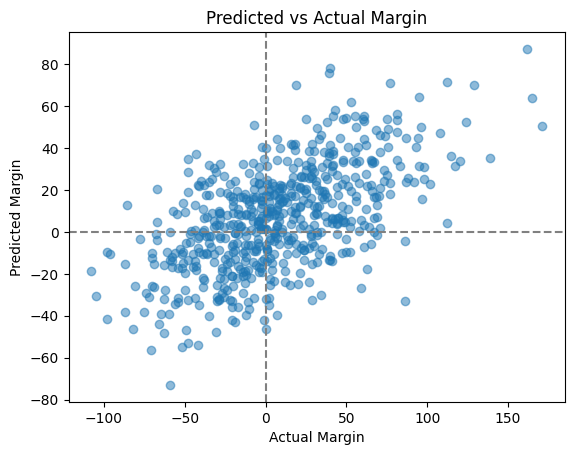

{"actual": [21.0, 67.0, 23.0, -61.0, 67.0, 18.0, -24.0, -71.0, 28.0, -29.0, -50.0, -6.0, 61.0, -41.0, 24.0, 33.0, -56.0, -8.0, -58.0, -98.0, -35.0, 7.0, -44.0, 24.0, 10.0, -37.0, -19.0, -35.0, -28.0, 7.0, -17.0, 7.0, 17.0, 86.0, -19.0, -13.0, 70.0, 58.0, -17.0, 2.0, -70.0, -10.0, -98.0, -18.0, -4.0, -48.0, 35.0, -3.0, -59.0, -21.0, 16.0, 56.0, -105.0, 49.0, 40.0, 19.0, -81.0, -9.0, 4.0, 1.0, 115.0, 8.0, 67.0, -86.0, 41.0, 92.0, 69.0, 4.0, 22.0, 15.0, -70.0, 38.0, 19.0, 12.0, 63.0, -8.0, 117.0, -2.0, 37.0, -38.0, 81.0, 33.0, 1.0, 5.0, 7.0, 44.0, 53.0, -74.0, 120.0, -57.0, 1.0, -30.0, -20.0, 58.0, -11.0, 165.0, -14.0, 139.0, -25.0, 21.0, -22.0, -7.0, -1.0, -24.0, -39.0, -20.0, 25.0, 9.0, 83.0, 40.0, -28.0, -10.0, -29.0, 76.0, 65.0, -4.0, 8.0, 39.0, 30.0, -35.0, -41.0, -30.0, 32.0, -38.0, 0.0, 32.0, -1.0, -43.0, 26.0, 3.0, 17.0, 62.0, -2.0, 71.0, 47.0, -87.0, 42.0, 13.0, 13.0, 25.0, -12.0, -51.0, 66.0, -25.0, 29.0, 23.0, 27.0, -28.0, -31.0, -3.0, 67.0, 1.0, -13.0, 65.0, -82.0, -41.0, -49.

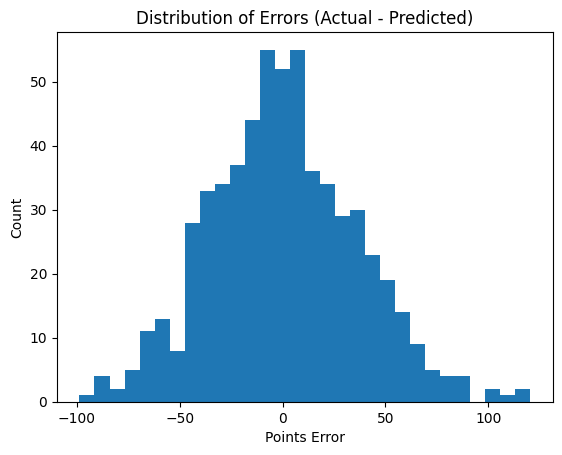

Actual margin min/max: -108.0 171.0
Predicted margin min/max: -73.02350074380162 87.43599110638556


In [36]:
# Margin, not just win/loss
feature_cols = [
    'poly_impact_diff',
    'elo_diff',
    'age_diff',
    'distance_from_home',
    'interstate',
    'neutral_venue',
    'momentum_diff'
]
feature_cols = [col for col in feature_cols if col in df_games_features.columns]

X_margin = df_games_features[feature_cols].copy()
y_margin = df_games_features['margin'].astype(float)

# Standardize numeric features
numeric_cols = ['poly_impact_diff', 'elo_diff', 'age_diff', 'distance_from_home']
numeric_cols = [col for col in numeric_cols if col in X_margin.columns]

scaler = StandardScaler()
X_margin[numeric_cols] = scaler.fit_transform(X_margin[numeric_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X_margin, y_margin, test_size=0.2, random_state=42
)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred_margin = reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_margin)
rmse = mean_squared_error(y_test, y_pred_margin) ** 0.5

print(f"MAE (Mean Absolute Error): {mae:.2f} points")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} points")
mean_margin = y_train.mean()
mae_baseline = mean_absolute_error(y_test, [mean_margin]*len(y_test))
print(f"Baseline MAE (predicting mean): {mae_baseline:.2f} points")


plt.scatter(y_test, y_pred_margin, alpha=0.5)
plt.xlabel("Actual Margin")
plt.ylabel("Predicted Margin")
plt.title("Predicted vs Actual Margin")
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.show()

# After you already have y_test and y_pred_margin from your regression
scatter_data = {
    "actual": y_test.tolist(),
    "predicted": y_pred_margin.tolist()
}
import json

# OR print it (to paste into the site manually)
print(json.dumps(scatter_data))

plt.hist(y_test - y_pred_margin, bins=30)
plt.title("Distribution of Errors (Actual - Predicted)")
plt.xlabel("Points Error")
plt.ylabel("Count")
plt.show()

print("Actual margin min/max:", y_test.min(), y_test.max())
print("Predicted margin min/max:", y_pred_margin.min(), y_pred_margin.max())


In [ ]:
# Evaluate models
models = [
    ('LogisticRegression', LogisticRegression(max_iter=1000)),
    ('RandomForest', RandomForestClassifier(n_estimators=100)),
    ('SVM', SVC(probability=True))
]

feature_cols = ['poly_impact_diff', 'elo_diff', 'age_diff', 'interstate']
# Add more features if they exist and you want them
feature_cols = [col for col in feature_cols if col in df_games_features.columns]

X = df_games_features[feature_cols]
y = (df_games_features['home_result'] == 'W').astype(int)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models:
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    print(f"{name}: Mean Accuracy={scores.mean():.3%} Std={scores.std():.3%}")

LogisticRegression: Mean Accuracy=69.406% Std=1.751%
RandomForest: Mean Accuracy=65.600% Std=1.833%
SVM: Mean Accuracy=67.890% Std=1.964%
